# Project 2: SQL - Driven Data Analysis

In [5]:
# Load libraries

import pandas as pd
import psycopg2
import warnings

In [6]:
warnings.filterwarnings('ignore')

## Problem Statement

As part of a role at a recruitment agency specializing in IT professionals, data related to job vacancies for Data Scientist positions will be analyzed through SQL queries. The focus is on the Data Understanding phase, where SQL queries executed via the `psycopg2` library will be used to explore and assess the dataset, ensuring proficiency in retrieving and analyzing data to support 
recruitment goals.

For the analysis we will use real data from one of the largest job search portals in Russia - [hh.ru](https://hh.ru/)

**Business Task**

Key characteristics of Data Scientist job vacancies will be identified using SQL-based analysis to enhance the recruitment agency’s ability to match candidates with suitable opportunities.

**Technical Task**

As a Data Science specialist, data will be retrieved and analyzed from a SQL database using the `psycopg2` library, with an emphasis on developing and executing SQL queries to uncover insights about Data Scientist job vacancies.

**Main Objectives**

* `SQL Query Proficiency`: SQL queries will be crafted and executed to thoroughly explore the dataset’s structure, content, and quality.

* `Insight Extraction`: Patterns related to job vacancies, employers, and industry trends will be uncovered through SQL-based analysis to inform recruitment strategies.

* `Data Relevance Confirmation`: The dataset’s suitability for supporting the agency’s recruitment objectives for Data Scientist positions will be verified using SQL queries.

In [ ]:
# Set a connection to database 

#DBNAME = 'dbname'
#USER = 'username'
#PASSWORD = 'password'
#HOST = 'host'
#PORT = 'port'

connection = psycopg2.connect(
   dbname=DBNAME,
   user=USER,
   host=HOST,
   password=PASSWORD,
   port=PORT
)

A schema of the dataset, including tables contained in the database and their relationships, will be presented:

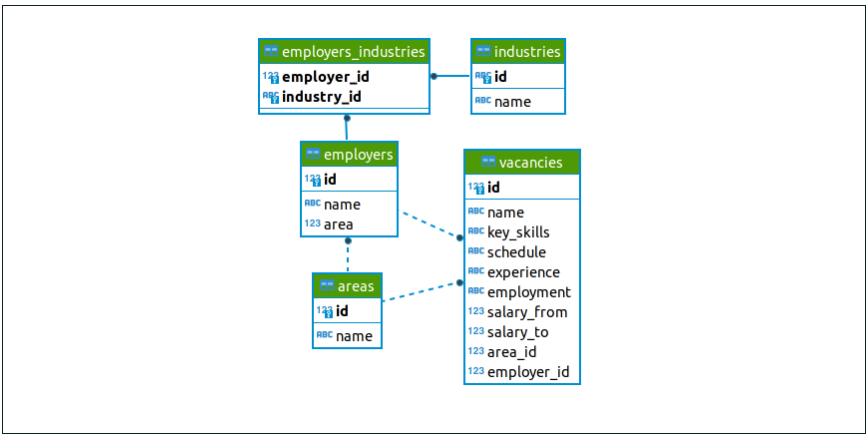

## 1. Preliminary Data Analysis

The data will be explored, and the number of vacancies, employers, regions, and industries will be determined. The following tables will be used:

- `vacancies`
- `employers`
- `areas`
- `industries`

In [8]:
# A query will be composed to count the number of vacancies in the database (vacancies are stored in the vacancies table).

query_3_1 = f'''
    SELECT COUNT(v.id)
    FROM public.vacancies as v
    '''
    
# Result of the query

df = pd.read_sql_query(query_3_1, connection);
print(f'Number of vacancies in the database: {df['count'][0]}')

Number of vacancies in the database: 49197


In [9]:
# A query will be composed to count the number of employers (employers table).

query_3_2 = f'''
    SELECT COUNT(e.id)
    FROM public.employers as e
    '''

# Result of the query

df = pd.read_sql_query(query_3_2, connection)
print(f'Number of employers in the database: {df['count'][0]}')

Number of employers in the database: 23501


In [10]:
# A query will be composed to count the number of regions (areas table).

query_3_3 = f'''
    SELECT COUNT(a.id)
    FROM public.areas as a
    '''

# Result of the query

df = pd.read_sql_query(query_3_3, connection)
print(f'Number of regions in the database: {df['count'][0]}')

Number of regions in the database: 1362


In [11]:
# A query will be composed to count the number of industries in the database (industries table).

query_3_4 = f'''
    SELECT COUNT(i.id)
    FROM public.industries as i
    '''

# Result of the query

df = pd.read_sql_query(query_3_4, connection)
print(f'Number of industries in the database: {df['count'][0]}')

Number of industries in the database: 294


***

### Conclusions from Preliminary Data Analysis

The database consists of:

- 49197 vacancies;

- 23501 employers;

- Vacancies located in 1362 different regions;

- Covering 294 industries.

On average, each employer posts 2.09 vacancies

## 2. Detailed Vacancy Analysis

A more focused analysis of vacancies will be conducted, examining the number of vacancies per region, checking the completion of salary fields, identifying salary ranges, and analyzing the distribution of vacancies by schedule, employment type, and required experience.

The following tables will be used:

- `vacancies`
- `areas`

In [12]:
# A query will be composed to determine the number of vacancies (cnt) in each region (area).
# Results will be sorted by the number of vacancies in descending order.

limit = 5

query_4_1 = f'''
    SELECT 
        COUNT(v.id) as vacancies_count,
        a.name as area
    FROM public.vacancies as v
    JOIN public.areas as a on v.area_id = a.id
    GROUP BY a.name
    ORDER BY vacancies_count DESC
    LIMIT {limit}
    '''
    
# Result of the query

df = pd.read_sql_query(query_4_1, connection)
df

,vacancies_count,area
0,5333,Москва
1,2851,Санкт-Петербург
2,2112,Минск
3,2006,Новосибирск
4,1892,Алматы


In [13]:
# A query will be composed to determine how many vacancies have at least one of the two salary fields filled.

query_4_2 = f'''
    SELECT 
        COUNT(v.id)
    FROM public.vacancies as v
    WHERE v.salary_from IS NOT NULL OR v.salary_to IS NOT NULL
    '''
    
# Result of the query

df = pd.read_sql_query(query_4_2, connection)
print(f'Number of vacancies with at least one salary field filled: {df['count'][0]}')

Number of vacancies with at least one salary field filled: 24073


In [14]:
# Average values for the lower and upper bounds of the salary range will be calculated, rounded to the nearest integer.

query_4_3 = f'''
    SELECT 
        ROUND(AVG(v.salary_from)) avg_min_salary,
        ROUND(AVG(v.salary_to)) avg_max_salary
    FROM public.vacancies as v
    WHERE v.salary_from IS NOT NULL OR v.salary_to IS NOT NULL
    '''

# Result of the query

df = pd.read_sql_query(query_4_3, connection)
print(f'Average value for the lower bound of the salary range: {df['avg_min_salary'][0]}')
print(f'Average value for the upper bound of the salary range: {df['avg_max_salary'][0]}')

Average value for the lower bound of the salary range: 71065.0
Average value for the upper bound of the salary range: 110537.0


In [15]:
# A query will be composed to output the number of vacancies for each combination of work schedule (schedule) and employment type (employment) used in vacancies.
# Results will be sorted by the number of vacancies in descending order.

limit = 1
offset = 1

query_4_4 = f'''
    SELECT
        v.schedule || ' - ' || v.employment as type,
        COUNT(*) as cnt
    FROM public.vacancies as v
    GROUP BY v.schedule || ' - ' || v.employment
    ORDER BY cnt DESC
    OFFSET {offset}
    LIMIT {limit}
    '''

# Result of the query

df = pd.read_sql_query(query_4_4, connection)
df

,type,cnt
0,Удаленная работа - Полная занятость,7802


In [16]:
# A query will be composed to output the values of the Required Experience (experience) field, sorted by the number of vacancies specifying each experience level in ascending order.

limit = 1
offset = 1

query_4_5 = f'''
    SELECT
        COUNT(*) as cnt,
        v.experience
    FROM public.vacancies as v
    GROUP BY v.experience
    ORDER BY cnt ASC
    '''

# Result of the query

df = pd.read_sql_query(query_4_5, connection)
df

,cnt,experience
0,1337,Более 6 лет
1,7197,Нет опыта
2,14511,От 3 до 6 лет
3,26152,От 1 года до 3 лет


***

### Conclusions from Detailed Vacancy Analysis

- The highest number of vacancies is posted in Moscow.
- A trend is observed toward increasing demand for remote work.
- Only 50% of vacancies include salary information.
- 55% of vacancies require at least minimal experience, while 15% require no experience.
- In 35% of cases, the average upper salary bound exceeds the lower bound in salary ranges.

## 3. Detailed Employer Analysis

A more focused analysis of employers posting vacancies will be conducted, examining which employers post the most vacancies, the distribution of employers by region, their industries, and the number of vacancies from employers in Russian cities with populations over one million.

The following tables will be used:

- vacancies
- employers
- areas
- industries
- employer-industries

In [17]:
# A query will be composed to identify the employers ranking first and fifth by the number of vacancies.

limit = 1
offset = 4

query_5_1 = f'''
    (
        SELECT
            COUNT(*) as cnt,
            e.name
        FROM public.vacancies as v
        JOIN public.employers as e on v.employer_id = e.id
        GROUP BY e.name
        ORDER BY cnt DESC
        LIMIT {limit}
    )
    UNION
    (
        SELECT
            COUNT(*) as cnt,
            e.name
        FROM public.vacancies as v
        JOIN public.employers as e on v.employer_id = e.id
        GROUP BY e.name
        ORDER BY cnt DESC
        OFFSET {offset}
        LIMIT {limit}
    )
    ORDER BY cnt DESC
    '''
    
# Result of the query

df = pd.read_sql_query(query_5_1, connection)
df

,cnt,name
0,1933,Яндекс
1,331,Газпром нефть


In [18]:
# A query will be composed to output the number of employers and vacancies for each region.
# Among regions with no vacancies, the region with the highest number of employers will be identified.


limit = 1

query_5_2 = f'''
        SELECT
            a.name as name,
            COUNT(v.id) as vacancies_count,
            COUNT(DISTINCT e.id) as employers_count
        FROM public.areas as a
        LEFT JOIN public.employers as e on a.id = e.area
        LEFT JOIN public.vacancies as v on a.id = v.area_id
        WHERE v.id is null
        GROUP BY a.name
        ORDER BY employers_count DESC
        LIMIT {limit}
        '''

# Result of the query

df = pd.read_sql_query(query_5_2, connection)
print(f'In the region {df['name'][0]}, the highest number of employers ({df['employers_count'][0]}) have not posted vacancies.')

In the region Россия, the highest number of employers (410) have not posted vacancies.


In [19]:
# For each employer, the number of regions in which they post vacancies will be calculated.
# Results will be sorted by the number of regions in descending order.

limit = 1

query_5_3 = f'''
        SELECT
            e.name as name,
            COUNT(distinct a.id) as area_count
        FROM public.vacancies as v
        JOIN public.employers as e on v.employer_id = e.id
        JOIN public.areas as a on a.id = v.area_id
        GROUP BY e.name
        ORDER BY area_count DESC
        LIMIT {limit}
        '''
        
# Result of the query

df = pd.read_sql_query(query_5_3, connection)
print(f'{df['name'][0]} is the company posting vacancies in the highest number of regions: {df['area_count'][0]}')

Яндекс is the company posting vacancies in the highest number of regions: 181


In [20]:
# A query will be composed to count the number of employers with no specified industry.

query_5_4 = f'''
        SELECT
            COUNT(distinct e.id) as employers_count
        FROM public.employers as e
        FULL OUTER JOIN public.employers_industries as ei on e.id = ei.employer_id
        WHERE ei.industry_id is null
        '''

# Result of the query

df = pd.read_sql_query(query_5_4, connection)
print(f'{df['employers_count'][0]} companies do not provide information about their industry.')

8419 companies do not provide information about their industry.


In [21]:
# A query will be composed to identify the name of the company ranking third in an alphabetical list of companies with exactly four specified industries.

limit = 1
offset = 2

query_5_5 = f'''
        SELECT
            e.name as employer_name,
            COUNT(ei.industry_id)
        FROM public.employers as e
        FULL OUTER JOIN public.employers_industries as ei on e.id = ei.employer_id
        GROUP BY e.name
        HAVING COUNT(ei.industry_id) = 4
        ORDER BY 1 ASC
        OFFSET {offset}
        LIMIT {limit}
        '''

# Result of the query

df = pd.read_sql_query(query_5_5, connection)
df

,employer_name,count
0,2ГИС,4


In [22]:
# A query will be composed to determine the number of employers listing "Software Development" as their industry.

query_5_6 = f'''
        SELECT
            COUNT(ei.employer_id)
        FROM public.employers_industries as ei
        JOIN public.industries as i on ei.industry_id = i.id
        WHERE i.name LIKE 'Разработка программного обеспечения%'
        '''

# Result of the query

df = pd.read_sql_query(query_5_6, connection)
print(f'{df['count'][0]} companies are engaged in software development.')

3553 companies are engaged in software development.


For the company "`Yandex`," a list of million-plus population cities in Russia with the number of vacancies in each will be output, along with a `Total` row showing the overall number of vacancies. Results will be sorted by the number of vacancies in ascending order.

The list of million-plus cities will be sourced from [this page](https://ru.wikipedia.org/wiki/%D0%93%D0%BE%D1%80%D0%BE%D0%B4%D0%B0-%D0%BC%D0%B8%D0%BB%D0%BB%D0%B8%D0%BE%D0%BD%D0%B5%D1%80%D1%8B_%D0%A0%D0%BE%D1%81%D1%81%D0%B8%D0%B8).

The `requests` and `BeautifulSoup` libraries will be used to retrieve additional data.

In [23]:
# Code to retrieve the list of million-plus cities

import requests 
from bs4 import BeautifulSoup 

url = 'https://ru.wikipedia.org/wiki/%D0%93%D0%BE%D1%80%D0%BE%D0%B4%D0%B0-%D0%BC%D0%B8%D0%BB%D0%BB%D0%B8%D0%BE%D0%BD%D0%B5%D1%80%D1%8B_%D0%A0%D0%BE%D1%81%D1%81%D0%B8%D0%B8'

# Retrieve page content

response = requests.get(url)

# Set encoding

response.encoding = 'utf-8'  

# Parse HTML code

page = BeautifulSoup(response.text, 'html.parser')

# Locate the table with million-plus cities

table = page.find('table', class_='standard')

# Extract data from the table

cities = []
for row in table.find_all('tr')[1:]: 
    cols = row.find_all('td')
    if len(cols) > 1:
        city = cols[1].text.strip()
        cities.append(city)

print(f'A list of million-plus population cities in Russia: \n {cities}')

A list of million-plus population cities in Russia: 
 ['Москва', 'Санкт-Петербург', 'Новосибирск', 'Екатеринбург', 'Казань', 'Красноярск', 'Нижний Новгород', 'Челябинск', 'Уфа', 'Краснодар', 'Самара', 'Ростов-на-Дону', 'Омск', 'Воронеж', 'Пермь', 'Волгоград']


In [24]:
# For the company "Yandex," a list of million-plus cities with the number of vacancies in each will be output.

cities_str = ', '.join(f"'{city}'" for city in cities)

query_5_7 = f'''
    WITH x AS ( 
        SELECT
            a.name as name,
            COUNT(v.id) AS cnt
        FROM public.vacancies AS v
        JOIN public.employers AS e ON v.employer_id = e.id
        JOIN public.areas AS a ON v.area_id = a.id
        WHERE e.name = 'Яндекс' AND a.name IN ({cities_str})
        GROUP BY a.name
    )
    SELECT
        name,
        cnt
    FROM x
    UNION ALL
    SELECT
        'Total' AS name,
        SUM(cnt) AS cnt
    FROM x
    '''
    
# Result of the query

df = pd.read_sql_query(query_5_7, connection)
print(f'Number of cities in the resulting table: {df.shape[0]-1}')
df

Number of cities in the resulting table: 16


,name,cnt
0,Волгоград,24.0
1,Воронеж,32.0
2,Екатеринбург,39.0
3,Казань,25.0
4,Краснодар,30.0
5,Красноярск,23.0
6,Москва,54.0
7,Нижний Новгород,36.0
8,Новосибирск,35.0
9,Омск,21.0


***

### Conclusions from Employer Analysis

- **Yandex** is the company posting the highest number of vacancies — **1933**.

- **In the region 'Russia', the highest number of employers (410)** have not posted vacancies.

- **"Yandex"** posts vacancies in the highest number of regions: **181**.

- **8419 companies do not provide information about their industry**, accounting for **36%** of all employers.

- **15% of companies** in the database are engaged in software development.

- **485 vacancies** were posted by "Yandex" in million-plus cities, representing **25%** of the company’s total vacancies.

- **1% of vacancies in Moscow** are posted by "Yandex".


## 4. Domain-Specific Data Analysis

A domain-specific analysis will be conducted, focusing on extracting data related to `Data Scientist` (DS) vacancies.

The number of vacancies related to data will be determined. Vacancies will be considered data-related if their titles contain the words '`data`' or '`данн`'.

Additionally, the number of vacancies suitable for `junior DS specialists`, the distribution of vacancies by key skills, employer requirements, and salary expectations for DS specialists will be analyzed.

The following table will be used:

- `vacancies`

In [25]:
# The number of vacancies related to data will be determined.

query_6_1 = f'''
        SELECT
            COUNT(v.id)
        FROM public.vacancies as v
        WHERE lower(v.name) LIKE '%data%' OR lower(v.name) LIKE '%данн%'
        '''

# Result of the query

df = pd.read_sql_query(query_6_1, connection)
print(f'{df['count'][0]} vacancies are related to data in the database.')

1771 vacancies are related to data in the database.


Vacancies for data scientists will be defined as those with titles containing at least one of the following terms:

- `'data scientist'`
- `'data science'`
- `'исследователь данных'`
- `'ML' (excluding HTML-related vacancies)`
- `'machine learning'`
- `'машинн%обучен%'`

**Subsequent queries will be based on these conditions**

The number of suitable vacancies for a `junior data scientist` will be determined.
Vacancies for junior-level specialists will include those where:

- The title contains the word '`junior`', *or*
- The required experience is `"No experience"`, *or*
- The employment type is '`Стажировка`' (Internship).
 

In [26]:
# The number of suitable vacancies for a junior data scientist will be determined.

query_6_2 = f'''
    SELECT
        COUNT(*)
    FROM public.vacancies as v
    WHERE 
        (
            v.name ILIKE '%data scientist%' OR
            v.name ILIKE '%data science%' OR
            v.name ILIKE '%исследователь данных%' OR
            (v.name ILIKE '%ML%' AND v.name NOT ILIKE '%HTML%') OR
            v.name ILIKE '%machine learning%' OR
            v.name ILIKE '%машинн%обучен%'
        )
        AND
        (
            v.name ILIKE '%junior%' OR
            v.experience = 'Нет опыта' OR
            v.employment = 'Стажировка'
        )
    '''

# Result of the query

df = pd.read_sql_query(query_6_2, connection)
print(f'{df['count'][0]} suitable vacancies for a junior data scientist.')

51 suitable vacancies for a junior data scientist.


In [27]:
# The number of DS vacancies listing SQL or PostgreSQL as a key skill will be determined.

query_6_3 = f'''
        SELECT
            COUNT(v.id)
        FROM public.vacancies AS v
        WHERE 
            (
                v.name ILIKE '%data scientist%' OR
                v.name ILIKE '%data science%' OR
                v.name ILIKE '%исследователь данных%' OR
                (v.name ILIKE '%ML%' AND v.name NOT ILIKE '%HTML%') OR
                v.name ILIKE '%machine learning%' OR
                v.name ILIKE '%машинн%обучен%'
            )
            AND
            (
                v.key_skills ILIKE '%SQL%' OR
                v.key_skills ILIKE '%postgres%'
            )
        '''

# Result of the query

df = pd.read_sql_query(query_6_3, connection)
print(f'{df['count'][0]} DS vacancies list SQL or PostgreSQL as a key skill.')

229 DS vacancies list SQL or PostgreSQL as a key skill.


In [28]:
# The number of vacancies listing Python as a key skill will be calculated to assess its popularity in DS employer requirements.

query_6_4 = f'''
        SELECT
            COUNT(v.id)
        FROM public.vacancies AS v
        WHERE 
            (
                v.name ILIKE '%data scientist%' OR
                v.name ILIKE '%data science%' OR
                v.name ILIKE '%исследователь данных%' OR
                (v.name ILIKE '%ML%' AND v.name NOT ILIKE '%HTML%') OR
                v.name ILIKE '%machine learning%' OR
                v.name ILIKE '%машинн%обучен%'
            )
            AND
                v.key_skills ILIKE '%python%'
        '''

# Result of the query

df = pd.read_sql_query(query_6_4, connection)
print(f'{df['count'][0]} vacancies list Python as a key skill.')

357 vacancies list Python as a key skill.


In [29]:
# The average number of key skills listed in DS vacancies will be examined.

query_6_5 = f'''
        SELECT
            ROUND(AVG(LENGTH(v.key_skills) - LENGTH(REPLACE(v.key_skills, CHR(9),'')) + 1),2) as c
        FROM public.vacancies AS v
        WHERE 
            (
                v.name ILIKE '%data scientist%' OR
                v.name ILIKE '%data science%' OR
                v.name ILIKE '%исследователь данных%' OR
                (v.name LIKE '%ML%' AND v.name NOT ILIKE '%HTML%') OR 
                v.name ILIKE '%machine learning%' OR
                v.name ILIKE '%машинн%обучен%'
            )
        '''

# Result of the query

df = pd.read_sql_query(query_6_5, connection)
print(f'{df['c'][0]} key skills are listed on average in DS vacancies.')

6.41 key skills are listed on average in DS vacancies.


A query will be composed to calculate the average salary for DS vacancies for each level of required experience (unique values from the experience field).

The following will be considered:

1. Only vacancies with at least one salary field filled will be included.

2. If both salary fields are filled, the salary will be calculated as the average of the two fields. If only one field is filled, that value will be used.

3. To handle null values, the [coalesce](https://postgrespro.ru/docs/postgresql/9.5/functions-conditional#functions-coalesce-nvl-ifnull) function will be used to replace null with a specified value (`e.g., select 1 + coalesce(null, 0)`).


In [30]:
# The average salary for a data scientist with 3 to 6 years of experience will be determined.

query_6_6 = f'''
    SELECT
        v.experience,
        ROUND(AVG(
            CASE
                WHEN v.salary_from IS NOT NULL AND v.salary_to IS NOT NULL THEN (v.salary_from + v.salary_to) / 2
                WHEN v.salary_from IS NOT NULL THEN v.salary_from
                WHEN v.salary_to IS NOT NULL THEN v.salary_to
            END
        )) as average_salary
    FROM public.vacancies AS v
    WHERE 
        (
            v.name ILIKE '%data scientist%' OR
            v.name ILIKE '%data science%' OR
            v.name ILIKE '%исследователь данных%' OR
            (v.name LIKE '%ML%' AND v.name NOT ILIKE '%HTML%') OR
            v.name ILIKE '%machine learning%' OR
            v.name ILIKE '%машинн%обучен%'
        )
        AND (v.salary_from IS NOT NULL OR v.salary_to IS NOT NULL)
    GROUP BY v.experience
    --HAVING v.experience = 'От 3 до 6 лет'
    '''

# Result of the query

df = pd.read_sql_query(query_6_6, connection)
df

,experience,average_salary
0,Нет опыта,74643.0
1,От 1 года до 3 лет,139675.0
2,От 3 до 6 лет,243115.0


***

### Conclusions from Domain-Specific Analysis

- **1771 vacancies are related to data** in the database, representing **8%** of the total.

- **51 suitable vacancies for a junior data scientist** exist.

- **229 DS vacancies** list **SQL or PostgreSQL** as a key skill.

- **357 vacancies** list **Python** as a key skill.

- **6.41 key skills are listed on average** in DS vacancies.

- The average salary for candidates with **3+ years of experience is 3.25 times higher** than for those with no experience.

## 5. Overall Project Conclusions

### General Project Conclusions

#### Dataset Overview

- The dataset contains many vacancies in IT or related fields.

- Vacancies span nearly every region, including some from other countries, with foreign vacancies offering better conditions but being fewer in number.

- The dataset contains potential outliers, particularly in salary data, suggesting data cleaning may be necessary for further analysis.

#### Trends and Forecasts

- Vacancies related to technology and data are likely to remain in demand, driven by ongoing digital transformation trends.

- Salaries for experienced professionals are expected to grow, especially in high-tech and in-demand fields.

- Cities with developed infrastructure and economies will continue to attract more vacancies and offer higher salaries.

- IT and innovation-related industries will remain at the forefront, as evidenced by the high number of vacancies in these sectors.

### Additional Queries Beyond the Data Analysis

Additional queries will be practiced to further explore the database contents.

In [31]:
# Top 10 vacancies in the database

query_7_1 = f'''
    SELECT
        v.name,
        COUNT(v.id) AS vacancy_count
    FROM public.vacancies AS v
    GROUP BY v.name
    ORDER BY vacancy_count DESC
    LIMIT 10
    '''

# Result of the query

df = pd.read_sql_query(query_7_1, connection)
df

,name,vacancy_count
0,Системный администратор,1761
1,Программист 1С,1153
2,Бизнес-аналитик,488
3,Специалист технической поддержки,457
4,Системный аналитик,432
5,Аналитик,404
6,Инженер-программист,389
7,Программист 1C,360
8,Frontend-разработчик,242
9,Инженер технической поддержки,230


In [32]:
# Distribution of average salaries by required experience

query_7_2 = f'''
    SELECT
        v.experience,
        ROUND(AVG(
            CASE
                WHEN v.salary_from IS NOT NULL AND v.salary_to IS NOT NULL THEN (v.salary_from + v.salary_to) / 2
                WHEN v.salary_from IS NOT NULL THEN v.salary_from
                WHEN v.salary_to IS NOT NULL THEN v.salary_to
            END
        )) AS average_salary
    FROM public.vacancies AS v
    WHERE (v.salary_from IS NOT NULL OR v.salary_to IS NOT NULL)
    GROUP BY v.experience
    ORDER BY average_salary DESC
    '''

df = pd.read_sql_query(query_7_2, connection)
df

,experience,average_salary
0,Более 6 лет,166256.0
1,От 3 до 6 лет,133211.0
2,От 1 года до 3 лет,76541.0
3,Нет опыта,40472.0


In [33]:
# Top 10 average salaries by region

query_7_3 = f'''
    SELECT
        a.name AS area,
        ROUND(AVG(
            CASE
                WHEN v.salary_from IS NOT NULL AND v.salary_to IS NOT NULL THEN (v.salary_from + v.salary_to) / 2
                WHEN v.salary_from IS NOT NULL THEN v.salary_from
                WHEN v.salary_to IS NOT NULL THEN v.salary_to
            END
        )) AS average_salary
    FROM public.vacancies AS v
    JOIN public.areas AS a ON v.area_id = a.id
    WHERE (v.salary_from IS NOT NULL OR v.salary_to IS NOT NULL)
    GROUP BY a.name
    ORDER BY average_salary DESC
    LIMIT 10
    '''

df = pd.read_sql_query(query_7_3, connection)
df

,area,average_salary
0,Германия,452751.0
1,Болгария,324348.0
2,Испания,300000.0
3,Черногория,288589.0
4,Литва,263019.0
5,Польша,257156.0
6,Петропавловка (Республика Бурятия),250000.0
7,Турция,235435.0
8,Кипр,223736.0
9,Кутаиси,220475.0


In [34]:
# Top 10 industries by number of vacancies

query_7_4 = f'''
    SELECT
        i.name AS industry,
        COUNT(v.id) AS vacancy_count
    FROM public.vacancies AS v
    JOIN public.employers AS e ON v.employer_id = e.id
    JOIN public.employers_industries AS ei ON e.id = ei.employer_id
    JOIN public.industries AS i ON ei.industry_id = i.id
    GROUP BY i.name
    ORDER BY vacancy_count DESC
    LIMIT 10
    '''

df = pd.read_sql_query(query_7_4, connection)
df

,industry,vacancy_count
0,Разработка программного обеспечения,12499
1,"Системная интеграция, автоматизации технологи...",11034
2,"Интернет-компания (поисковики, платежные систе...",6413
3,Банк,2742
4,Мобильная связь,1585
5,Кадровые агентства,1143
6,Консалтинговые услуги,1137
7,Интернет-провайдер,1095
8,Розничная сеть (продуктовая),1034
9,Фиксированная связь,1028


In [35]:
# Top 10 industries by average salary

query_7_5 = f'''
    SELECT
        i.name AS industry,
        ROUND(AVG(
            CASE
                WHEN v.salary_from IS NOT NULL AND v.salary_to IS NOT NULL THEN (v.salary_from + v.salary_to) / 2
                WHEN v.salary_from IS NOT NULL THEN v.salary_from
                WHEN v.salary_to IS NOT NULL THEN v.salary_to
            END
        )) AS average_salary
    FROM public.vacancies AS v
    JOIN public.employers AS e ON v.employer_id = e.id
    JOIN public.employers_industries AS ei ON e.id = ei.employer_id
    JOIN public.industries AS i ON ei.industry_id = i.id
    WHERE (v.salary_from IS NOT NULL OR v.salary_to IS NOT NULL)
    GROUP BY i.name
    ORDER BY average_salary DESC
    LIMIT 10
    '''

df = pd.read_sql_query(query_7_5, connection)
df

,industry,average_salary
0,"Агрохимия (продвижение, оптовая торговля)",381429.0
1,Агрохимия (производство),339875.0
2,Игорный бизнес,191905.0
3,Корма для животных (производство),168300.0
4,Зоомагазин,167613.0
5,Кадровые агентства,144530.0
6,"Лакокрасочная продукция, сырье (производство)",142803.0
7,"Бытовая химия, парфюмерия, косметика (произво...",130120.0
8,"Лакокрасочная продукция, сырье (продвижение, о...",128445.0
9,"Дорожно-строительная техника, сельскохозяйстве...",122878.0


In [36]:
# Number of vacancies by key skills listed

query_7_6 = f'''
    SELECT
        unnest(string_to_array(v.key_skills, CHR(9))) AS skill,
        COUNT(v.id) AS vacancy_count
    FROM public.vacancies AS v
    GROUP BY skill
    ORDER BY vacancy_count DESC
    LIMIT 10
    '''

df = pd.read_sql_query(query_7_6, connection)
df

,skill,vacancy_count
0,SQL,6977
1,Git,4731
2,Английский язык,4525
3,Работа в команде,3923
4,Linux,3747
5,JavaScript,3625
6,Python,3445
7,Управление проектами,2764
8,1С программирование,2647
9,PostgreSQL,2452


In [37]:
# Top 10 employers by average offered salary

query_7_7 = f'''
    SELECT
        e.name AS employer_name,
        ROUND(AVG(
            CASE
                WHEN v.salary_from IS NOT NULL AND v.salary_to IS NOT NULL THEN (v.salary_from + v.salary_to) / 2
                WHEN v.salary_from IS NOT NULL THEN v.salary_from
                WHEN v.salary_to IS NOT NULL THEN v.salary_to
            END
        )) AS average_salary
    FROM public.vacancies AS v
    JOIN public.employers AS e ON v.employer_id = e.id
    WHERE (v.salary_from IS NOT NULL OR v.salary_to IS NOT NULL)
    GROUP BY e.name
    ORDER BY average_salary DESC
    LIMIT 10
    '''

df = pd.read_sql_query(query_7_7, connection)
df

,employer_name,average_salary
0,Alpha Personnel,1000000.0
1,ЦТП,650000.0
2,RuWork,555261.0
3,Петухова Алия,552700.0
4,Агентство недвижимости ЛЕТО,550000.0
5,Пикабу,550000.0
6,BeRecruited,550000.0
7,ВСП Партнер,500000.0
8,"Август, Фирма",500000.0
9,StaffRecruitment,483333.0


## 6. Closing the Connection

In [38]:
# The database connection will be closed after completing the analysis.

connection.close()